In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
df = pd.read_csv('Mall_Customers.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 5)

First 5 rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Dataset Info:")
print(df.info())
print("\nNull Values:")
print(df.isnull().sum())
print("\nStatistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Null Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
print(df.columns.tolist())
print(df.head())

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


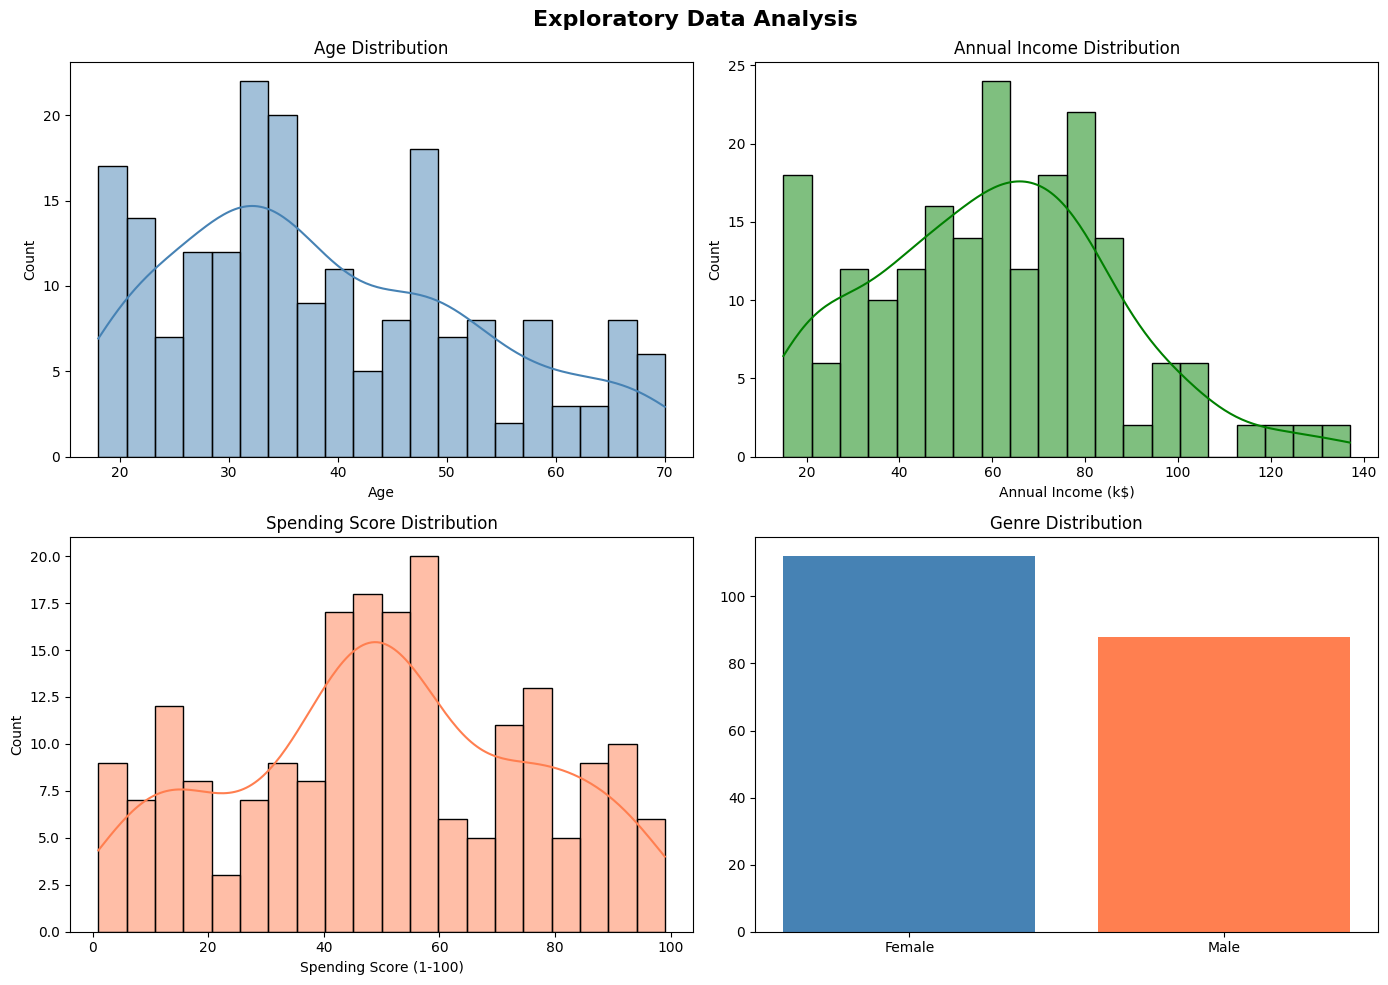

✅ EDA complete!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Age distribution
sns.histplot(df['Age'], bins=20, ax=axes[0,0], color='steelblue', kde=True)
axes[0,0].set_title('Age Distribution')

# Annual Income distribution
sns.histplot(df['Annual Income (k$)'], bins=20, ax=axes[0,1], color='green', kde=True)
axes[0,1].set_title('Annual Income Distribution')

# Spending Score distribution
sns.histplot(df['Spending Score (1-100)'], bins=20, ax=axes[1,0], color='coral', kde=True)
axes[1,0].set_title('Spending Score Distribution')

# Genre count
genre_counts = df['Genre'].value_counts()
axes[1,1].bar(genre_counts.index, genre_counts.values, color=['steelblue','coral'])
axes[1,1].set_title('Genre Distribution')

plt.tight_layout()
plt.show()
print("✅ EDA complete!")

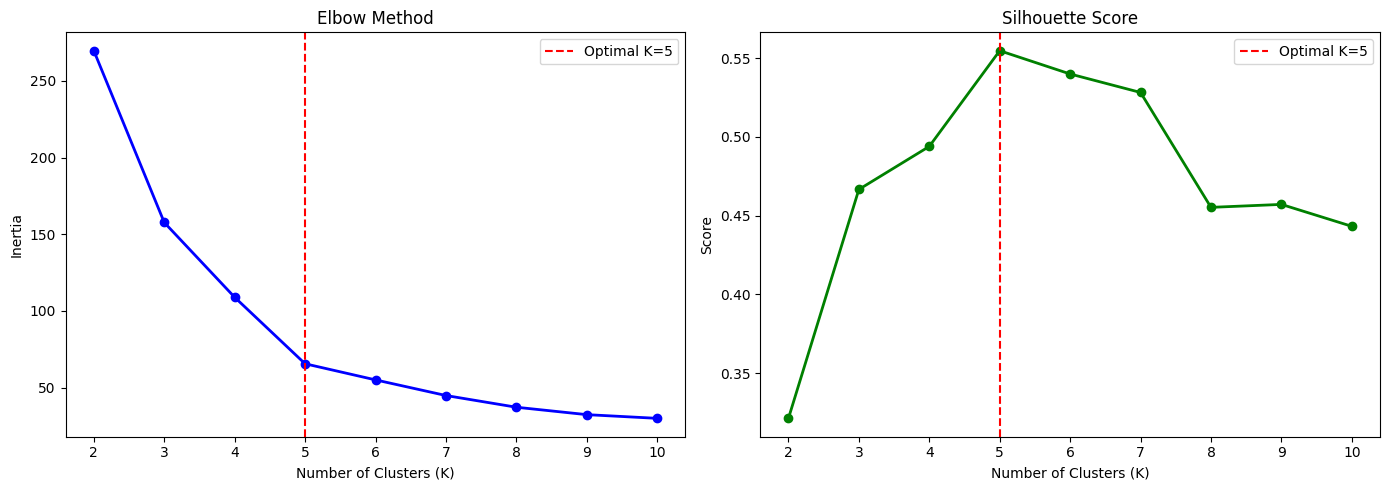

✅ Optimal K = 5


In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
axes[1].legend()

plt.tight_layout()
plt.show()
print("✅ Optimal K = 5")

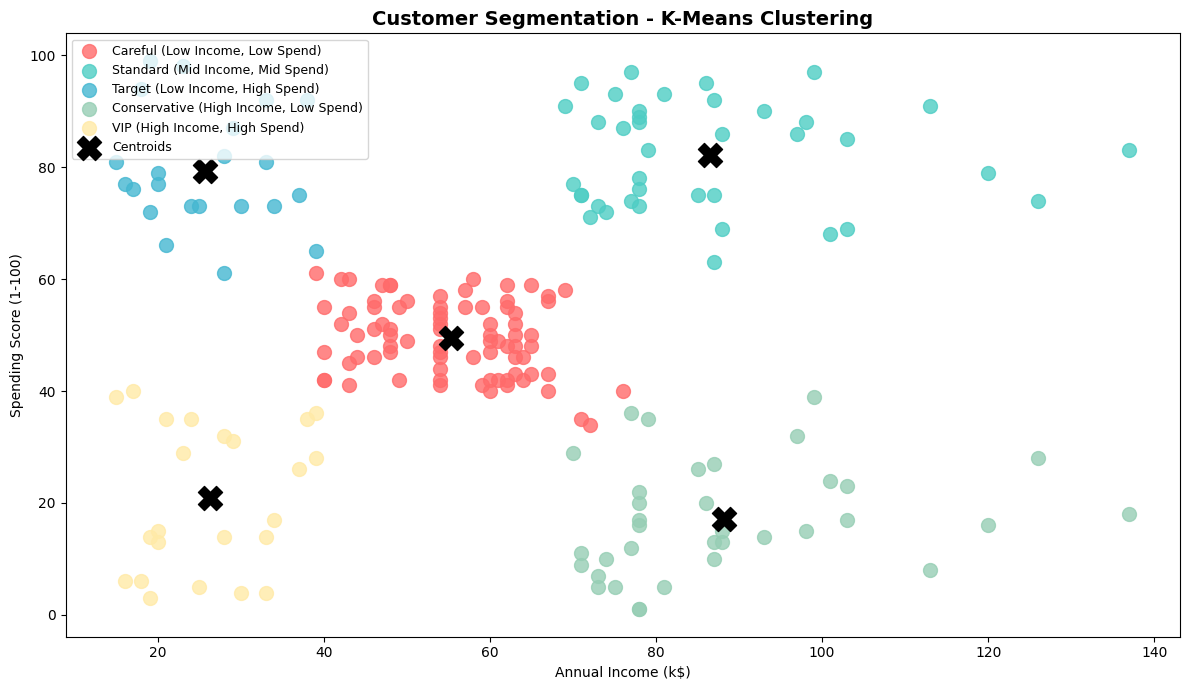

✅ Clustering done!


In [7]:
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
labels = ['Careful (Low Income, Low Spend)',
          'Standard (Mid Income, Mid Spend)',
          'Target (Low Income, High Spend)',
          'Conservative (High Income, Low Spend)',
          'VIP (High Income, High Spend)']

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[i], label=labels[i], s=100, alpha=0.8)

centers = scaler.inverse_transform(km_final.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=300, zorder=5, label='Centroids')

plt.title('Customer Segmentation - K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
print("✅ Clustering done!")

In [8]:
segment_map = {
    0: 'Careful Spenders',
    1: 'Standard Customers',
    2: 'Impulsive Spenders',
    3: 'Conservative Customers',
    4: 'VIP Customers'
}
df['Segment'] = df['Cluster'].map(segment_map)

summary = df.groupby('Segment').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending_Score=('Spending Score (1-100)', 'mean')
).round(2)

print("📊 Segment Summary:")
print(summary)

📊 Segment Summary:
                        Count  Avg_Age  Avg_Income  Avg_Spending_Score
Segment                                                               
Careful Spenders           81    42.72       55.30               49.52
Conservative Customers     35    41.11       88.20               17.11
Impulsive Spenders         22    25.27       25.73               79.36
Standard Customers         39    32.69       86.54               82.13
VIP Customers              23    45.22       26.30               20.91


In [9]:
import os
os.makedirs('outputs', exist_ok=True)

df.to_csv('outputs/customer_segments.csv', index=False)
summary.to_csv('outputs/segment_summary.csv')

print("✅ Files saved!")
print("\n📁 Output files:")
print("  - outputs/customer_segments.csv")
print("  - outputs/segment_summary.csv")

✅ Files saved!

📁 Output files:
  - outputs/customer_segments.csv
  - outputs/segment_summary.csv
